<center> <img src="https://miro.medium.com/v2/resize:fit:1200/1*lbDXL0IuitCRz4mpZ7MmfQ.png" width=55% > </center>

<br><br>

<center> 
    <font size="6">Final Lab (Part 2): Image Classification using Convolutional Neural Networks </font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, October 18, 2024 (Amsterdam time)</font> 
</center>
<center> 
    <font size="4"><b>TA's:  Yue, Konrad & Thies</b></font>
</center>

<br><br>

***

<br><br>

<center>

Student1 ID: 15823725 \
Student1 Name: Alisia Baielli

Student2 ID: 13995995 \
Student2 Name: Sander Hoffman

Student3 ID: 15667669 \
Student3 Name: Maxim Voronin

( Student4 ID: \
Student4 Name: )

</center>

### **Coding Guidelines**

Your code must be handed in this Jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Final Lab: Image Classification Assignment. Please also fill out your names and IDs above.

For full credit, make sure your notebook follows these guidelines:

- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Understand the problem as much as you can. When answering a question, provide evidence (qualitative and/or quantitative results, references to papers, figures, etc.) to support your arguments. Not everything might be explicitly asked for, so think about what might strengthen your arguments to make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Add a number, a title, and, if applicable, the name and unit of variables in a table, and name and unit of axes and legends in a figure.

**Late submissions are not allowed.** Assignments submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance to avoid last-minute system failure issues.

**Environment:** Since this is a project-based assignment, you are free to use any feature descriptor and machine learning tools (e.g., K-means, SVM). You should use Python for your implementation. You are free to use any Python library for this assignment, but make sure to provide a conda environment file!

**Plagiarism Note:** Keep in mind that plagiarism (submitted materials which are not your work) is a serious offense and any misconduct will be addressed according to university regulations. This includes using generative tools such as ChatGPT.

**Ensure that you save all results/answers to the questions (even if you reuse some code).**

### **Report Preparation**

Your tasks include the following:

1. **Report Preparation:** For both parts of the final project, students are expected to prepare a report. The report should include all details on implementation approaches, analysis of results for different settings, and visualizations illustrating experiments and performance of your implementation. Grading will be based on the report, so it should be as self-contained as possible. If the report contains faulty results or ambiguities, TAs can refer to your code for clarification. 

2. **Explanation of Results:** Do not just provide numbers without explanation. Discuss different settings to show your understanding of the material and processes involved.

3. **Quantitative Evaluation:** For quantitative evaluation, you are expected to provide the results based on performance (accuracy, learning loss and learning curves). 

4. **Aim:** Understand the basic Image Classification pipeline using Convolutional Neural Nets (CNN's).

5. **Working on Assignments:** Students should work in assigned groups for **two** weeks. Any questions can be discussed on ED.

    - **Submission:** Submit your source code and report together in a zip file (`ID1_ID2_ID3_part2.zip`). The report should be a maximum of 10 pages (single-column, including tables and figures, excluding references and appendix). Express thoughts concisely. Tables and figures must be accompanied by a description. Number them and, if applicable, name variables in tables, and label axes in figures.

6. **Hyperparameter Search:** In your experiments, remember to perform a hyperparameter search to find the optimal settings for your model(s). Clearly document the search process, the parameters you explored, and how they influenced the performance of your model.

8. **Format and Testing:** The report should be in **PDF format**, and the code in **.ipynb format**. Test that all functionality works as expected in the notebook.

### **Overview**

- [Section 1: Image Classification on CIFAR-100 (0 points)](#section-1)
- [Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)](#section-2)
- [Section 3: TwoLayerNet Architecture (2 points)](#section-3)
- [Section 4: ConvNet Architecture (2 points)](#section-4)
- [Section 5: Preparation of Training (7 points)](#section-5)
- [Section 6: Training the Networks (5 points)](#section-6)
- [Section 7: Setting Up the Hyperparameters (14 points)](#section-7)
- [Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)](#section-8)
- [Section 9: Fine-tuning ConvNet on STL-10 (14 points)](#section-9)
- [Section 10: Bonus Challenge (optional)](#section-10)
- [Section X: Individual Contribution Report (Mandatory)](#section-x)

### **Section 1: Image Classification on CIFAR-100 (0 points)**

The goal of this lab is to implement an image classification system using Convolutional Neural Networks (CNNs) that can identify objects from a set of classes in the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). You will implement and compare two different architectures: a simple two-layer network and a ConvNet based on the LeNet architecture.

The CIFAR-100 dataset contains 32x32 pixel RGB images, categorized into 100 different classes. The dataset will be automatically downloaded and loaded using the code provided in this notebook.

You will train and test your classification system using the entire CIFAR-100 dataset. Ensure that the test images are excluded from training to maintain a fair evaluation of the model's performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from PIL import Image
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset, random_split

# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CIFAR-100 training set
train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Load the CIFAR-100 test set
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Create data loaders for the entire CIFAR-100 dataset
train_data_loader = DataLoader(train_set, shuffle=True)
test_data_loader = DataLoader(test_set, shuffle=False)

# Define CIFAR-100 superclasses and their subclasses
superclasses = {
    'aquatic mammals': ['beaver', 'dolphin', 'otter', 'seal', 'whale'],
    'fish': ['aquarium_fish', 'flatfish', 'ray', 'shark', 'trout'],
    'flowers': ['orchid', 'poppy', 'rose', 'sunflower', 'tulip'],
    'food containers': ['bottle', 'bowl', 'can', 'cup', 'plate'],
    'fruit and vegetables': ['apple', 'mushroom', 'orange', 'pear', 'sweet_pepper'],
    'household electrical devices': ['clock', 'keyboard', 'lamp', 'telephone', 'television'],
    'household furniture': ['bed', 'chair', 'couch', 'table', 'wardrobe'],
    'insects': ['bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'],
    'large carnivores': ['bear', 'leopard', 'lion', 'tiger', 'wolf'],
    'large man-made outdoor things': ['bridge', 'castle', 'house', 'road', 'skyscraper'],
    'large natural outdoor scenes': ['cloud', 'forest', 'mountain', 'plain', 'sea'],
    'large omnivores and herbivores': ['camel', 'cattle', 'chimpanzee', 'elephant', 'kangaroo'],
    'medium-sized mammals': ['fox', 'porcupine', 'possum', 'raccoon', 'skunk'],
    'non-insect invertebrates': ['crab', 'lobster', 'snail', 'spider', 'worm'],
    'people': ['baby', 'boy', 'girl', 'man', 'woman'],
    'reptiles': ['crocodile', 'dinosaur', 'lizard', 'snake', 'turtle'],
    'small mammals': ['hamster', 'mouse', 'rabbit', 'shrew', 'squirrel'],
    'trees': ['maple_tree', 'oak_tree', 'palm_tree', 'pine_tree', 'willow_tree'],
    'vehicles 1': ['bicycle', 'bus', 'motorcycle', 'pickup_truck', 'train'],
    'vehicles 2': ['lawn_mower', 'rocket', 'streetcar', 'tank', 'tractor']
}

# List of all CIFAR-100 classes
classes = ('apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
           'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
           'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
           'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
           'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
           'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
           'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
           'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower',
           'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
           'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm')

# Create a mapping of class names to their indices
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

# Create a mapping of superclasses to their corresponding class indices
superclass_to_indices = {supcls: [class_to_idx[cls] for cls in subclasses] for supcls, subclasses in superclasses.items()}

print("Data loaders for CIFAR-100 are ready for use.")

Files already downloaded and verified
Files already downloaded and verified
Data loaders for CIFAR-100 are ready for use.


# Important notes for TA

We commented out all of the training and dumping of data, so you can safely run all to see our results without having to wait hours!

In [2]:
# I needed to set this for my matplotlib to work for some reason, please comment this out if it causes errors in your environment.
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"


<a id="section-2"></a>
### **Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)**

In this section, you will implement a function to visualize the CIFAR-100 dataset, including **all** superclasses and their corresponding subclasses. Your implementation should provide a clear and organized overview of the dataset's diversity.

You add the figure(s) to appendix of your report and refer to it in the main text.

In [3]:

def visualize_cifar100_superclasses(train_set, superclasses, class_to_idx):
    num_superclasses = len(superclasses)
    num_subclasses_per_superclass = max(len(subclasses) for subclasses in superclasses.values())

    fig, axes = plt.subplots(num_superclasses, num_subclasses_per_superclass, figsize=(10, 40))
    fig.tight_layout(pad=1.0)

    for i, (superclass, subclasses) in enumerate(superclasses.items()):
        for j, subclass in enumerate(subclasses):
            subclass_idx = class_to_idx[subclass]

            for img, label in train_set:
                if label == subclass_idx:
                    img = img / 2 + 0.5
                    np_img = img.numpy()

                    axes[i, j].imshow(np.transpose(np_img, (1, 2, 0)))
                    axes[i, j].axis('off')
                    axes[i, j].set_title(f"{subclass}", fontsize=8)
                    break

        # Add a title for the superclass at the beginning of each row
        axes[i, 0].annotate(superclass, xy=(0, 0.5), xycoords=axes[i, 0].yaxis.label, size='large', ha='right', va='center')

    plt.show()



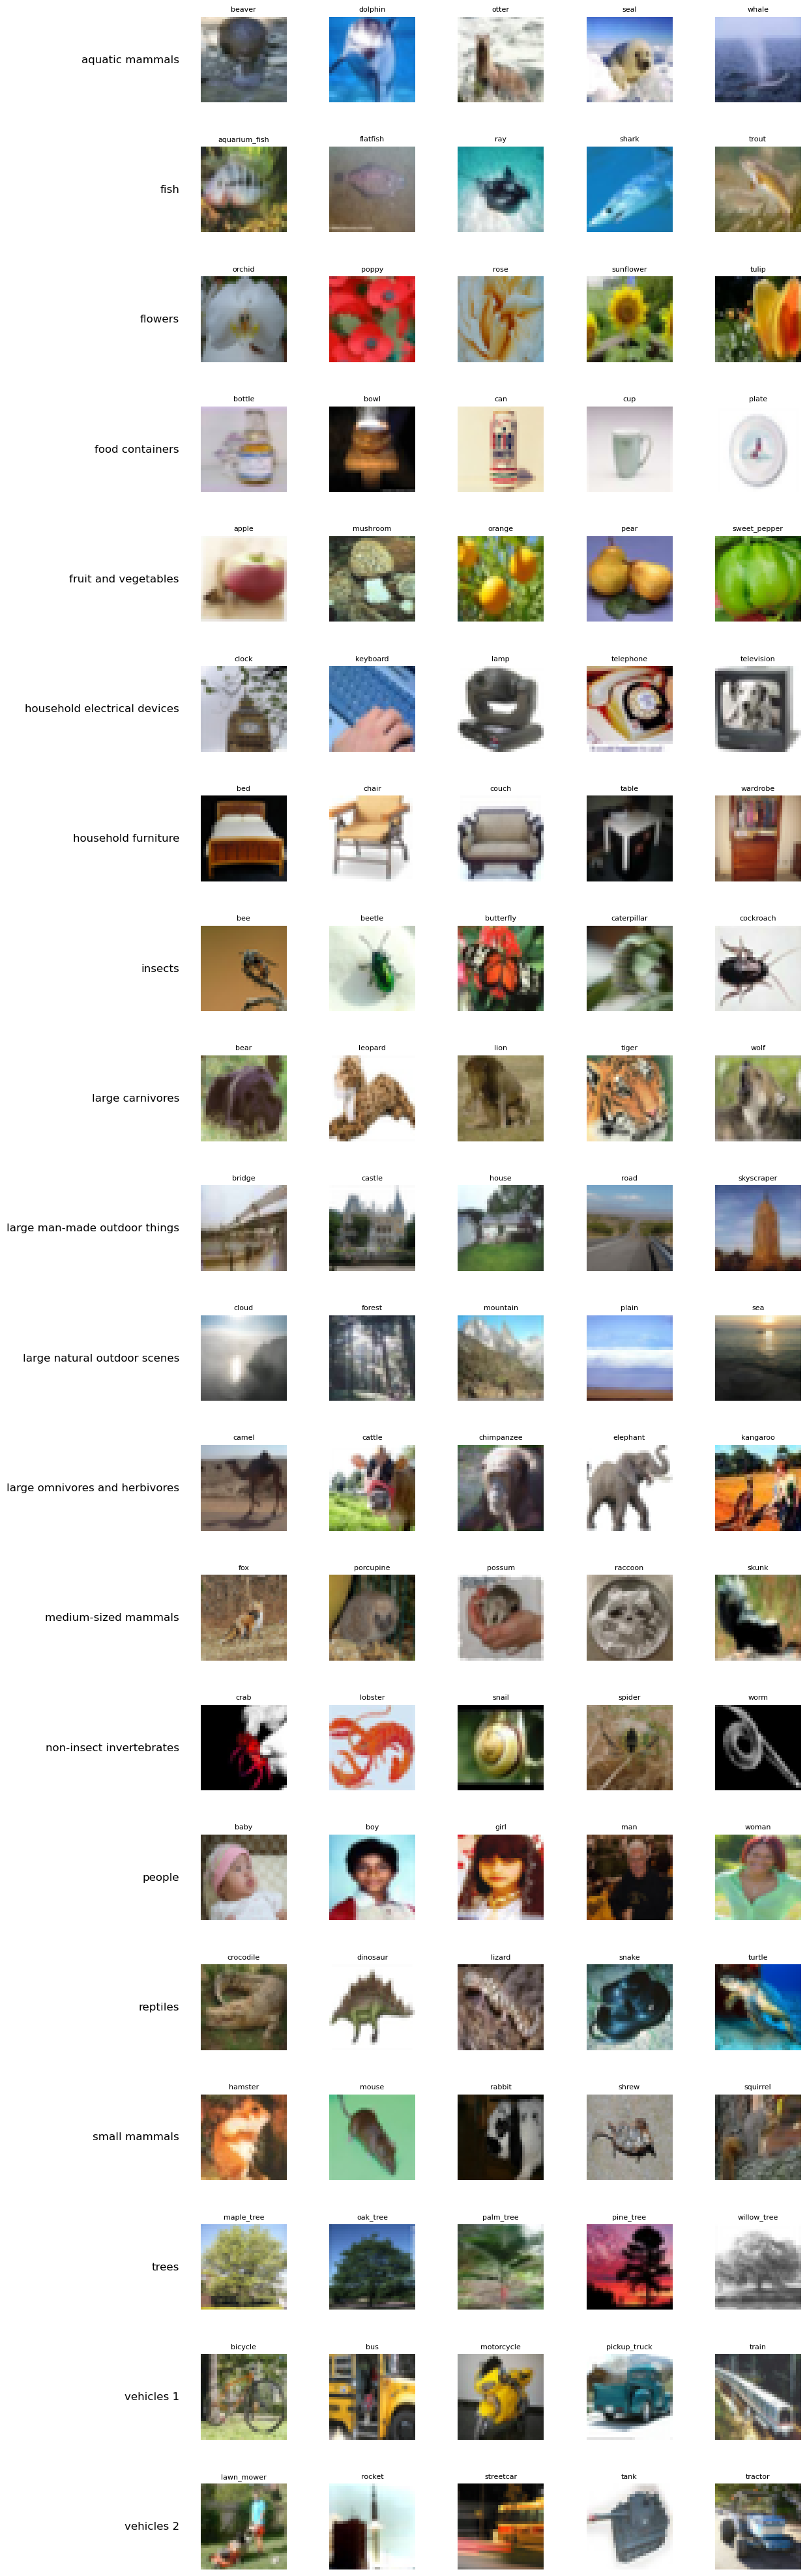

In [4]:
visualize_cifar100_superclasses(train_set, superclasses, class_to_idx)

<a id="section-3"></a>
### **Section 3: TwoLayerNet Architecture (2 points)**

In this section, you will implement the architecture of a fully connected neural network called `TwoLayerNet`, consisting of two fully connected layers with a ReLU activation in between. The network accepts an input size of 3x32x32 (CIFAR-100 image), a specified hidden layer size, and the number of output classes. In the `__init__` method, define the first fully connected layer that maps the input size to the hidden size, and the second fully connected layer that maps the hidden size to the number of classes. 

Ensure to call the parent class constructor using `super(TwoLayerNet, self).__init__()`. In the `forward` method, flatten the input tensor, pass it through the first layer with ReLU activation, and then through the second layer to obtain the final scores.

**Note:** You are allowed to modify the provided function definitions as needed.

In [5]:
class TwoLayerNet(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes, batch_norm = False, conv = False, hidden_size2 = 0):
        '''
        Initializes the two-layer neural network model.

        Args:
            input_size (int): The size of the input features.
            hidden_size (int): The size of the hidden layer.
            num_classes (int): The number of classes in the dataset.
        '''
        super(TwoLayerNet, self).__init__()

        if (batch_norm):
            self.batch_norm = nn.BatchNorm1d(hidden_size)
        else:
            self.batch_norm = None

        OUT_CHANNELS = 5

        if conv:
            self.conv = nn.Conv2d(3, OUT_CHANNELS, 5)
        else:
            self.conv = None
        
        if hidden_size2:
            self.fc3 = nn.Linear(hidden_size, hidden_size2)
        else:
            self.fc3 = None

        # For the parameter adjustment, assume 3 channels
        self.fc1 = nn.Linear((input_size if not conv else round(pow((np.sqrt(input_size / 3) - 4) / 2, 2) * OUT_CHANNELS)), hidden_size)

        self.fc2 = nn.Linear((hidden_size if not hidden_size2 else hidden_size2), num_classes)

        self.relu = nn.ReLU()

    def forward(self, x : torch.Tensor):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''

        if self.conv:
            x = nn.MaxPool2d(2)(self.relu(self.conv(x)))

        # Flatten
        x = x.view(x.size(0), -1)

        # Hidden activations
        h = self.relu(self.fc1(x))
        if self.batch_norm:
            h = self.batch_norm(h)
        if self.fc3:
            h = self.relu(self.fc3(h))

        # Output activations
        out = self.fc2(h)
        return out

<a id="section-4"></a>
### **Section 4: ConvNet Architecture (2 points)**

In this section, you will implement a convolutional neural network inspired by the structure of [LeNet-5](https://ieeexplore.ieee.org/document/726791). The network processes color images using three convolutional layers followed by two fully connected layers. Since you need to feed color images into this network, determine the kernel size of the first convolutional layer. Additionally, calculate the number of trainable parameters in the "F6" layer, providing the calculation process.

In [6]:
class ConvNet(nn.Module):

    def __init__(self, batch_norm = False, conv = False):
        '''
        Initializes the convolutional neural network model.

        Args:
            None
        '''
        # All comments assume conv is false.
        super(ConvNet, self).__init__()

        if (batch_norm):
            self.batch_norm_1 = nn.BatchNorm2d(6)
            self.batch_norm_2 = nn.BatchNorm2d(16)
        else:
            self.batch_norm_1 = None
            self.batch_norm_2 = None

        if conv:
            self.conv4 = nn.Conv2d(in_channels=16, out_channels=48, kernel_size=3)
            self.fc3 = nn.Linear(84, 84)
        else:
            self.conv4 = None
            self.fc3 = None

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)  # 32x32 -> 28x28 (no padding)

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5 - (conv * 2))  # 14x14 -> 10x10

        self.conv3 = nn.Conv2d(in_channels=16 + (conv * 32), out_channels=120 + (conv * 120), kernel_size=5)  # 5x5 -> 1x1

        self.fc1 = nn.Linear(120 + (conv * 120), 84)
        # Last layer has 84 * 100 + 100 = 8500 parameters
        self.fc2 = nn.Linear(84, 100)

        self.relu = nn.ReLU()

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''


        c1 = self.relu(self.conv1(x))  # Output: (6, 28, 28)
        if self.batch_norm_1:
            c1 = self.batch_norm_1(c1)
        s2 = nn.MaxPool2d(2)(c1)  # Output: (6, 14, 14)

        c3 = self.relu(self.conv2(s2))  # Output: (16, 10, 10)
        if self.batch_norm_2:
            c3 = self.batch_norm_2(c3)
        if self.conv4:
            c3 = self.conv4(c3)

        s4 = nn.MaxPool2d(2)(c3)  # Output: (16, 5, 5)

        c5 = self.relu(self.conv3(s4))  # Output: (120, 1, 1)

        # Flatten the output from (120, 1, 1) to (120)
        c5 = c5.view(-1, (120 if not self.conv4 else 240))

        f6 = self.relu(self.fc1(c5))  # Output: (84)
        if self.fc3:
            f6 = self.relu(self.fc3(f6))
        out = self.fc2(f6)  # Output: (100) (class scores)

        return out


<a id="section-5"></a>
### **Section 5: Preparation of Training (7 points)**

In this section, you will create a custom dataset class to load the CIFAR-100 data, define a transform function for data augmentation, and set up an optimizer for training. While the previous section utilized the built-in CIFAR-100 class from `torchvision`, in practice, you often need to prepare datasets manually. Here, you will implement the `CIFAR100_loader` class to handle the dataset and use `DataLoader` to make it iterable. You will also define a transform function for data augmentation and an optimizer for updating the model's parameters.

In [7]:
class CIFAR100_loader(Dataset):

    def __init__(self, root, train=True, transform=None, download=False):
        '''
        Initializes the CIFAR-100 dataset loader.

        Args:
            root (str): The root directory to store the dataset.
            train (bool): If True, loads the training data; otherwise, loads the test data.
            transform (callable, optional): The data transformations to apply.
            download (bool): If True, downloads the dataset if it is not already available.
        '''

        self.dataset = torchvision.datasets.CIFAR100(root=root, train=train, download=download)
        self.transform = transform

    def __len__(self):
        '''
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        '''

        return len(self.dataset)

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the image and label tensors.
        '''

        img, label = self.dataset[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [8]:
# Source: https://discuss.pytorch.org/t/passing-none-to-transform-compose-causes-a-problem/22602
class NoneTransform(object):
    """ Does nothing to the image, to be used instead of None

    Args:
        image in, image out, nothing is done
    """
    def __call__(self, image):
        return image

def create_transforms(flip = True, crop = 4, rot = 0, col = False):
    '''
    Creates the data transformations for the CIFAR-100 dataset.

    Returns:
        torchvision.transforms.Compose: The data transformations for the dataset.
    '''

    transform = transforms.Compose([
        (transforms.RandomHorizontalFlip() if flip else NoneTransform()),  # Randomly flip the image horizontally
        (transforms.RandomCrop(32, padding=crop) if crop else NoneTransform()), # Randomly crop the image with padding (amounts to shift)
        (transforms.RandomRotation(rot) if rot else NoneTransform()), # Randomly rotate the image.
        (transforms.ColorJitter(brightness= 0.01, saturation=0.01, hue=0.01) if col else NoneTransform()), # Randomly vary colours by 1%
        transforms.ToTensor(),  # Convert PIL Image to Tensor
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize with mean and std
    ])

    return transform

def create_test_transforms():
    '''
    Creates the test data transformations for the CIFAR-100 dataset.

    Returns:
        torchvision.transforms.Compose: The test data transformations for the dataset.
    '''

    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert PIL Image to Tensor
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize with mean and std
    ])

    return transform

In [9]:
def create_optimizer(model, learning_rate=0.001, optim="Adam", weight_decay = 0):
    '''
    Creates an optimizer for the model.

    Args:
        model (torch.nn.Module): The neural network model.
        learning_rate (float): The learning rate for the optimizer.
        optim (str): which optimiser to use
        weight_decay (float): The weight decay to use.

    Returns:
        torch.optim.Adam / torch.optim.SGD: The optimizer for the model.
    '''

    if optim == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optim == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    return optimizer

<a id="section-6"></a>
### **Section 6: Training the Networks (5 points)**

In this section, you will complete the `train` function and use it to train both the `TwoLayerNet` and `ConvNet` models. You will use the custom `CIFAR100_loader`, transform function, and optimizer function that you implemented. The goal is to compare the performance of the two models on the CIFAR-100 dataset.

In [10]:
def validate(net, testloader):
    '''
    Validates the model on the test dataset.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.

    Returns:
        float: The accuracy of the model on the test dataset.
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    correct, total = 0, 0

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f} %')

    return accuracy

In [11]:
def validate_per_class(net, testloader, classes):
    '''
    Validates the model on the test dataset per class.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.
        classes (tuple): The tuple of class names.

    Returns:
        None
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class_correct = [0. for _ in range(len(classes))]
    class_total = [0. for _ in range(len(classes))]

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            correct_predictions = (predicted == labels).squeeze()

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += correct_predictions[i].item()
                class_total[label] += 1

    for i, class_name in enumerate(classes):
        accuracy = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
        print(f'Accuracy of {class_name:5s} : {accuracy:.2f} %')

In [12]:
def train(net, train_loader, test_loader, criterion, optimizer, epochs=100, existing_train_loss=None, existing_test_loss=None, existing_accuracy=None, save_best = None):
    '''
    Trains the neural network model.

    Args:
        net (torch.nn.Module): The neural network model.
        train_loader (torch.utils.data.DataLoader): The data loader for the training dataset.
        test_loader (torch.utils.data.DataLoader): The data loader for the test dataset.
        criterion (torch.nn.Module): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer for the model.
        epochs (int): The number of epochs to train the model.

    Returns:
        dict: A dictionary containing lists of training and test losses for each epoch.
    '''

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Training on " + str(device))
    net.to(device)

    best_acc = 0

    train_losses = []
    if existing_train_loss:
        train_losses = existing_train_loss
    test_losses = []
    if existing_test_loss:
        test_losses = existing_test_loss
    test_accuracy = []
    if existing_accuracy:
        test_accuracy = existing_accuracy

    for epoch in range(epochs):
        net.train()
        running_loss = 0.0

        # Iterate over the data
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = net(inputs)

            # Calculate loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        net.eval()
        test_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = net(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                loss = criterion(outputs, labels)

                # Accumulate the test loss
                test_loss += loss.item()

        # Calculate average test loss and accuracy for this epoch
        accuracy = 100 * correct / total
        if accuracy > best_acc and save_best:
            torch.save(net.state_dict(), f"BEST{save_best}.pth")
            best_acc = accuracy
        test_accuracy.append(accuracy)
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')

    return {'train_loss': train_losses, 'test_loss': test_losses, 'accuracy': test_accuracy}

In [13]:
def plot_training_results(results):
    '''
    Plots training and test losses on one plot, and test accuracy on a separate subplot.

    Args:
        results (dict): Dictionary containing lists of 'train_loss', 'test_loss', and 'accuracy'.
    Returns:
        None
    '''

    # Extract data from the dictionary
    train_losses = results['train_loss']
    test_losses = results['test_loss']
    test_accuracies = results['accuracy']

    # Number of epochs based on the length of the loss/accuracy arrays
    epochs = range(1, len(train_losses) + 1)

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Training and Test Loss on the first subplot
    ax1.plot(epochs, train_losses, label='Training Loss', color='blue', linestyle='--', marker='o')
    ax1.plot(epochs, test_losses, label='Test Loss', color='red', linestyle='-', marker='x')
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Test Accuracy on the second subplot
    ax2.plot(epochs, test_accuracies, label='Test Accuracy', color='green', linestyle='-', marker='s')
    ax2.set_title('Test Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

# Transform visualisation

In [14]:
transformss = [create_transforms(False, 0, 0, False), create_transforms(True, 0, 0, True), create_transforms(True, 4, 30, True), create_transforms(True, 1, 5, True)]
train_set1 = CIFAR100_loader(root='./data', train=True, transform=None, download=True)

Files already downloaded and verified


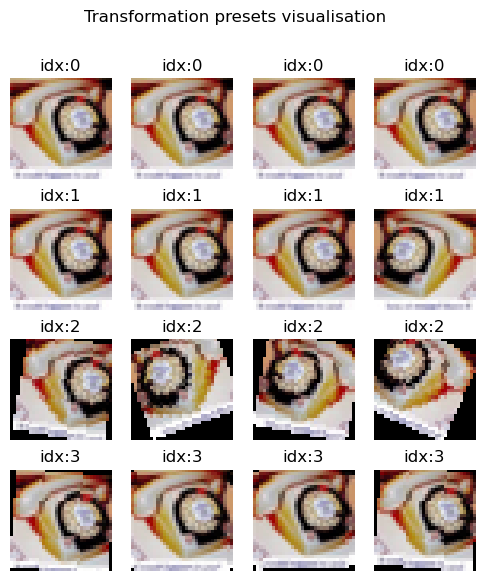

In [15]:
fig, axs = plt.subplots(4, 4)
# Visualise randomisation training data:
fig.suptitle("Transformation presets visualisation")
fig.set_size_inches(6, 6.5)
for i in range(4):
    for j in range(4):
        axs[i,j].set_title(f"idx:{i}")
        axs[i,j].axis('off')
        axs[i, j].imshow((np.transpose(transformss[i](train_set1[5][0]), (1, 2, 0)) + 1) / 2)
plt.show()


First, initialize the datasets and data loaders for both models.

In [16]:
SEED = 42
torch.manual_seed(SEED)  # For PyTorch
np.random.seed(SEED)      # For NumPy

# Set the CUDA seed if you are using a GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

transform = create_transforms(False, 0, 0, False)
test_transforms = create_test_transforms()

print(torch.__version__)
print("Running on " + ("cuda" if torch.cuda.is_available() else "cpu"))

train_set = CIFAR100_loader(root='./data', train=True, transform=transform, download=True)
# No random transforms on the test set
test_set = CIFAR100_loader(root='./data', train=False, transform=test_transforms, download=True)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, pin_memory=True)

# Initialize models
two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100)
conv_net = ConvNet()

criterion = nn.CrossEntropyLoss() # Cross entropy cause classes
optimizer_two_layer = create_optimizer(two_layer_net)
optimizer_conv_net = create_optimizer(conv_net)

2.3.1
Running on cpu
Files already downloaded and verified
Files already downloaded and verified


Next, train the TwoLayerNet model on the CIFAR-100 dataset using the training data loader.

In [17]:
# print("Training TwoLayerNet...")
# twolayer_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=25)

In [18]:
# torch.save(two_layer_net.state_dict(), "TwoLayerFullyConnected.pth")

Finally, train the ConvNet model on the CIFAR-100 dataset using the training data loader.

In [19]:
# print("Training ConvNet...")
# convnet_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=25)

In [20]:
# torch.save(conv_net.state_dict(), "ConvNet.pth")

In [21]:
# import json
# with open('resultsTL.json', 'w') as f:
#     json.dump(twolayer_training_data, f)
# with open('resultsCN.json', 'w') as f:
#     json.dump(convnet_training_data, f)

In [22]:
import json
with open('resultsTL.json', 'r') as f:
    base_twolayer = json.load(f)
with open('resultsCN.json', 'r') as f:
    base_conv = json.load(f)

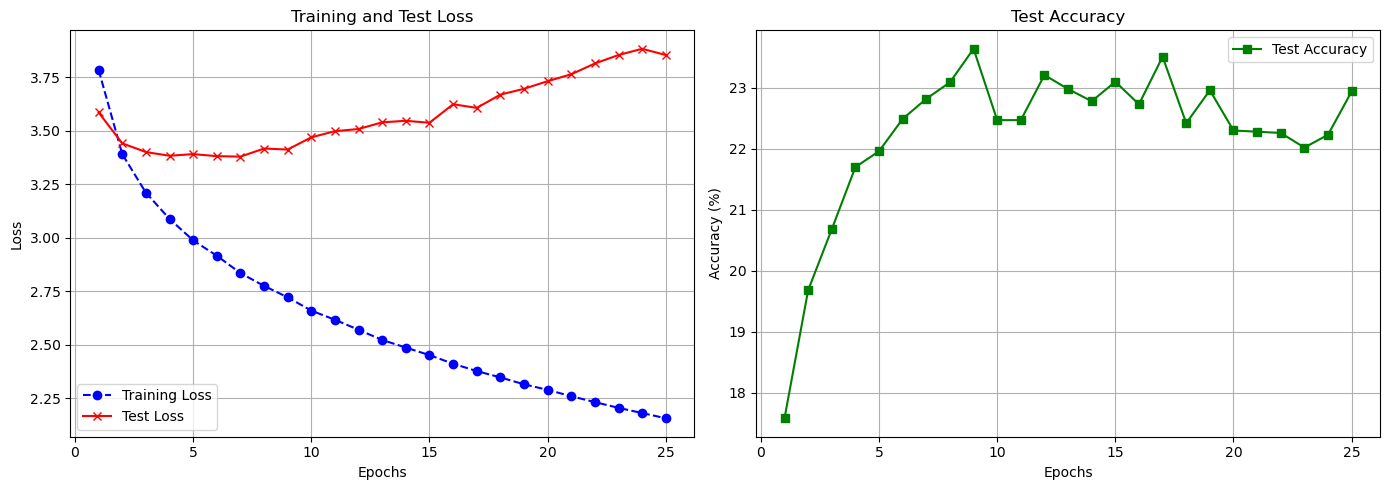

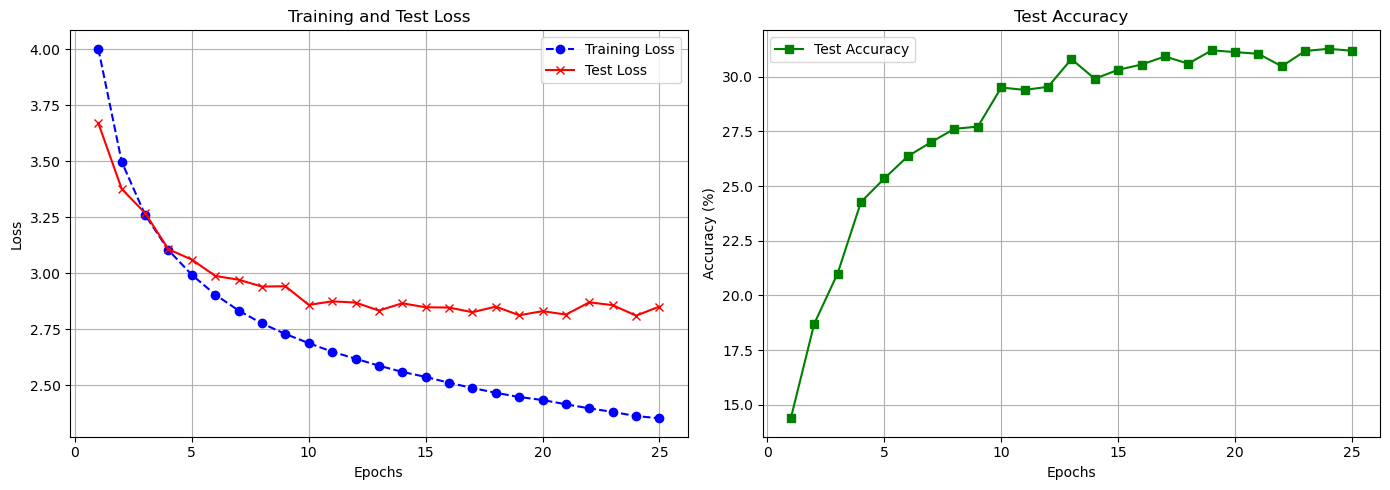

In [23]:
plot_training_results(base_twolayer)
plot_training_results(base_conv)

<a id="section-7"></a>
### **Section 7: Setting Up the Hyperparameters (14 points)**

In this section, you will experiment with both the `ConvNet` and `TwoLayerNet` models by setting up and tuning the hyperparameters to achieve the highest possible accuracy. You have the flexibility to modify the training process, including the `train` function, `DataLoader`, `transform` functions, and optimizer as needed.

1. Adjust the hyperparameters, including learning rate, batch size, number of epochs, optimizer, weight decay, and transform function to improve the performance of both networks. Modify the training procedure and architecture as necessary. You can also add components like Batch Normalization layers.
2. Add two more layers to both `TwoLayerNet` and `ConvNet`. You can decide the size and placement of these layers. Evaluate if these changes result in higher performance and explain your findings.
3. Show the final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both `TwoLayerNet` and `ConvNet`.
4. Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

**Note:** Do not use external pre-trained networks and limit additional convolutional layers to a maximum of three beyond the original architecture.

In [24]:
# Initialize models
two_layer_conv_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100, conv=True)
conv_conv_net = ConvNet(conv=True)

criterion = nn.CrossEntropyLoss() # Cross entropy cause classes
optimizer_two_layer_conv = create_optimizer(two_layer_conv_net)
optimizer_conv_net_conv = create_optimizer(conv_conv_net)

In [25]:
# # First test the models with extra convolutions:
# print("Training TwoLayerNet with conv...")
# twolayer_conv_training_data = train(two_layer_conv_net, train_loader, test_loader, criterion, optimizer_two_layer_conv, epochs=25)

In [26]:
# # First test the models with extra convolutions:
# print("Training convnet with conv...")
# conv_conv_training_data = train(conv_conv_net, train_loader, test_loader, criterion, optimizer_conv_net_conv, epochs=25)

In [27]:
# All parameters to vary
lr_values = [0.01, 0.0001]
batch_size = [16, 512]
optimizer = ["SGD"]
weight_decay = [0.01, 0.1]
transformations = [create_transforms(True, 0, 0, True), create_transforms(True, 4, 30, True), create_transforms(True, 1, 5, True)]
batch_normalisation = [True]

# Parameter search is commented out, because we already did it, now we just load the jsons with the data.


In [28]:
# # lr:
# lr_data = []
# for lr in lr_values:
#     # Initialize models
#     two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100)
#     conv_net = ConvNet()

#     optimizer_two_layer = create_optimizer(two_layer_net, learning_rate= lr)
#     optimizer_conv_net = create_optimizer(conv_net, learning_rate = lr)

#     print("Training TwoLayerNet")
#     twolayer_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=25)

#     print("Training convnet with conv...")
#     conv_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=25)
#     lr_data.append({"twolayer": twolayer_training_data, "convnet": conv_training_data, "param": lr})

# with open('resultsLRDATA.json', 'w') as f:
#     json.dump(lr_data, f)

Test the performance of TwoLayerNet after hyperparameter tuning and compare it with the ConvNet model. Provide a detailed explanation of the results.

In [29]:
# # batch:
# batch_data = []
# for batch in batch_size:
#     # transform = create_transforms(False, False, 0, False)
#     # test_transforms = create_test_transforms()

#     # train_set = CIFAR100_loader(root='./data', train=True, transform=transform, download=True)
#     # # No random transforms on the test set
#     # test_set = CIFAR100_loader(root='./data', train=False, transform=test_transforms, download=True)

#     train_loader = DataLoader(train_set, batch_size=batch, shuffle=True, pin_memory=True)
#     test_loader = DataLoader(test_set, batch_size=batch, shuffle=False, pin_memory=True)
#     # Initialize models
#     two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100)
#     conv_net = ConvNet()

#     optimizer_two_layer = create_optimizer(two_layer_net)
#     optimizer_conv_net = create_optimizer(conv_net)

#     print("Training TwoLayerNet")
#     twolayer_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=25)

#     print("Training convnet with conv...")
#     conv_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=25)
#     batch_data.append({"twolayer": twolayer_training_data, "convnet": conv_training_data, "param": batch})

# with open('resultsBATCHDATA.json', 'w') as f:
#     json.dump(batch_data, f)

In [30]:
# # optim:
# optim_data = []
# for optim in optimizer:
#     train_loader = DataLoader(train_set, batch_size=64, shuffle=True, pin_memory=True)
#     test_loader = DataLoader(test_set, batch_size=64, shuffle=False, pin_memory=True)
#     # Initialize models
#     two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100)
#     conv_net = ConvNet()
#     optimizer_two_layer = create_optimizer(two_layer_net, optim=optim)
#     optimizer_conv_net = create_optimizer(conv_net, optim=optim)

#     print("Training TwoLayerNet")
#     twolayer_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=25)

#     print("Training convnet with conv...")
#     conv_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=25)
#     optim_data.append({"twolayer": twolayer_training_data, "convnet": conv_training_data, "param": optim})

# with open('resultsOPTIMDATA.json', 'w') as f:
#     json.dump(optim_data, f)

In [31]:
# # weight_decay:
# decay_data = []
# for wd in weight_decay:
#     # Initialize models
#     two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100)
#     conv_net = ConvNet()

#     optimizer_two_layer = create_optimizer(two_layer_net, weight_decay=wd)
#     optimizer_conv_net = create_optimizer(conv_net, weight_decay=wd)

#     print("Training TwoLayerNet")
#     twolayer_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=25)

#     print("Training convnet")
#     conv_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=25)
#     decay_data.append({"twolayer": twolayer_training_data, "convnet": conv_training_data, "param": wd})

# with open('resultsDECAYDATA.json', 'w') as f:
#     json.dump(decay_data, f)

In [32]:
# # Transform:
# transform_data = []
# for i, tr in enumerate(transformations):
#     # transform = create_transforms(False, False, 0, False)
#     # test_transforms = create_test_transforms()

#     train_set = CIFAR100_loader(root='./data', train=True, transform=tr, download=True)
#     # # No random transforms on the test set
#     # test_set = CIFAR100_loader(root='./data', train=False, transform=test_transforms, download=True)

#     train_loader = DataLoader(train_set, batch_size=64, shuffle=True, pin_memory=True)
#     # Initialize models
#     two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100)
#     conv_net = ConvNet()

#     optimizer_two_layer = create_optimizer(two_layer_net)
#     optimizer_conv_net = create_optimizer(conv_net)

#     print("Training TwoLayerNet")
#     twolayer_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=25)

#     print("Training convnet with conv...")
#     conv_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=25)
#     transform_data.append({"twolayer": twolayer_training_data, "convnet": conv_training_data, "param": i + 1})

# with open('resultsTRANSFORMDATA.json', 'w') as f:
#     json.dump(transform_data, f)

In [33]:
# # normalisation
# batch_norm_data = []
# for bn in batch_normalisation:
#     # Initialize models
#     two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=128, num_classes=100, batch_norm=bn)
#     conv_net = ConvNet(batch_norm=bn)

#     optimizer_two_layer = create_optimizer(two_layer_net)
#     optimizer_conv_net = create_optimizer(conv_net)

#     print("Training TwoLayerNet")
#     twolayer_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=25)

#     print("Training convnet with conv...")
#     conv_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=25)
#     batch_norm_data.append({"twolayer": twolayer_training_data, "convnet": conv_training_data, "param": bn})

# with open('resultsBATCHNORMDATA.json', 'w') as f:
#     json.dump(batch_norm_data, f)

In [34]:
def plot_hyperparameter_search_results(data, param_name, network_type='twolayer'):
    """
    Plots the training and test losses and accuracy for each configuration of batch normalization.

    Args:
        data (list): A list of dictionaries containing the training results for each network configuration.
        network_type (str): Either 'twolayer' or 'convnet' to specify which network results to plot.
    """
    plt.figure(figsize=(15, 5))

    # Create subplots for loss and accuracy
    ax1 = plt.subplot(1, 2, 1)
    ax2 = plt.subplot(1, 2, 2)

    for entry in data:
        param_value = entry['param']
        results = entry[network_type]
        
        # Plot train and test loss
        ax1.plot(results['train_loss'], label=f'Train Loss ({param_name}={param_value})', linestyle='--', marker='o')
        ax1.plot(results['test_loss'], label=f'Test Loss ({param_name}={param_value})', linestyle='-', marker='x')
        
        # Plot accuracy
        ax2.plot(results['accuracy'], label=f'Accuracy ({param_name}={param_value})', linestyle='-', marker='s')

    # Set titles, labels, and legends for both subplots
    ax1.set_title(f'{network_type.capitalize()} Training and Test Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.set_title(f'{network_type.capitalize()} Test Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [35]:
with open('./resultsTRANSFORMDATA.json', 'r') as f:
    transform_data = json.load(f)
with open('./resultsBATCHNORMDATA.json', 'r') as f:
    batch_norm_data = json.load(f)
with open('./resultsBATCHDATA.json', 'r') as f:
    batch_data = json.load(f)
with open('./resultsOPTIMDATA.json', 'r') as f:
    optim_data = json.load(f)
with open('./resultsLRDATA.json', 'r') as f:
    lr_data = json.load(f)
with open('./resultsDECAYDATA.json', 'r') as f:
    decay_data = json.load(f)

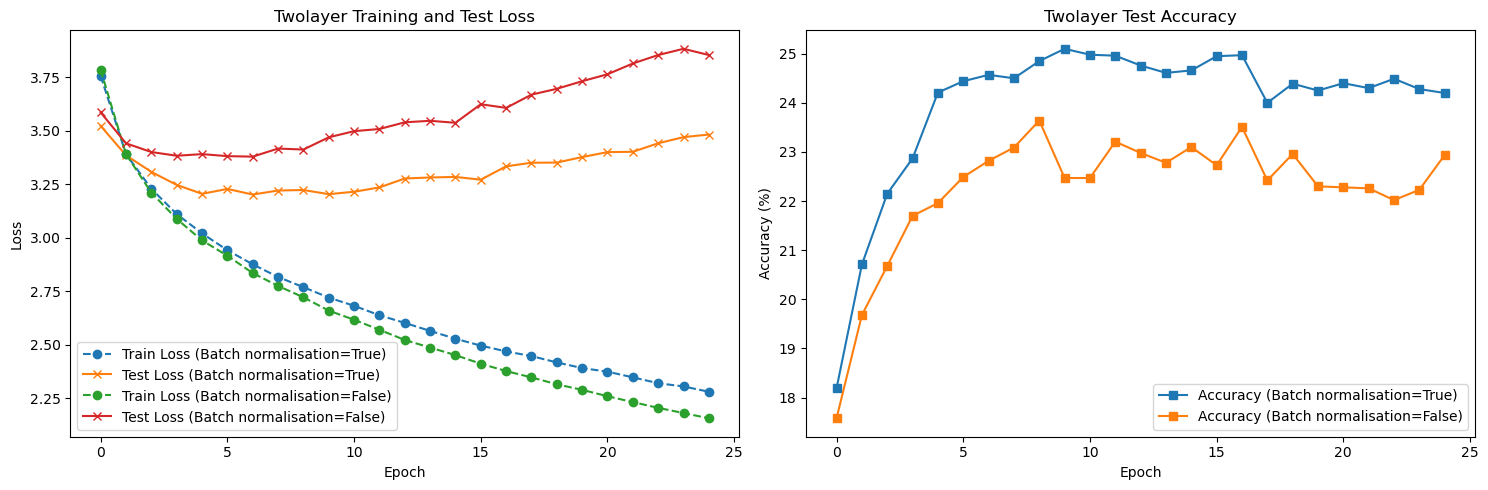

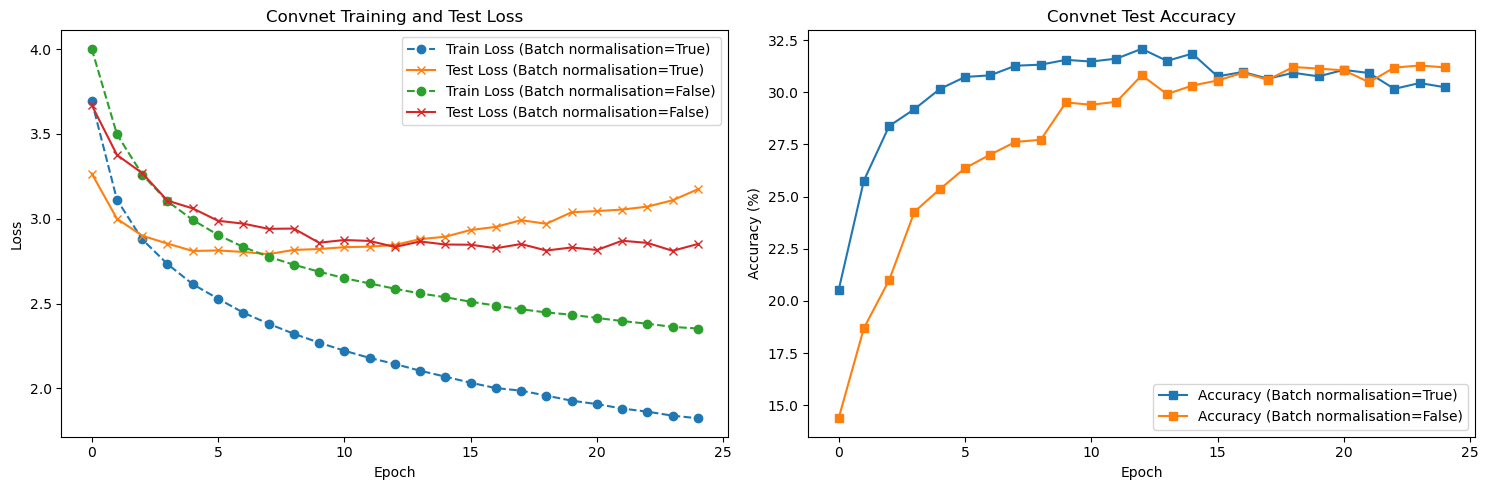

In [36]:
plot_hyperparameter_search_results(batch_norm_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": False}], "Batch normalisation")
plot_hyperparameter_search_results(batch_norm_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": False}], "Batch normalisation", "convnet")

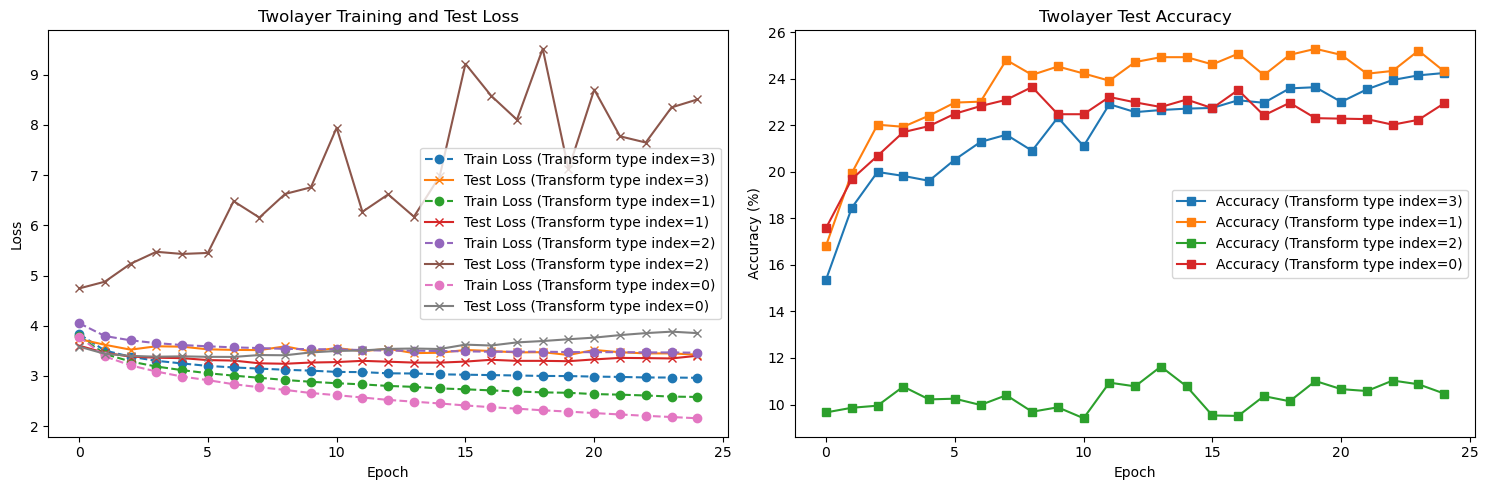

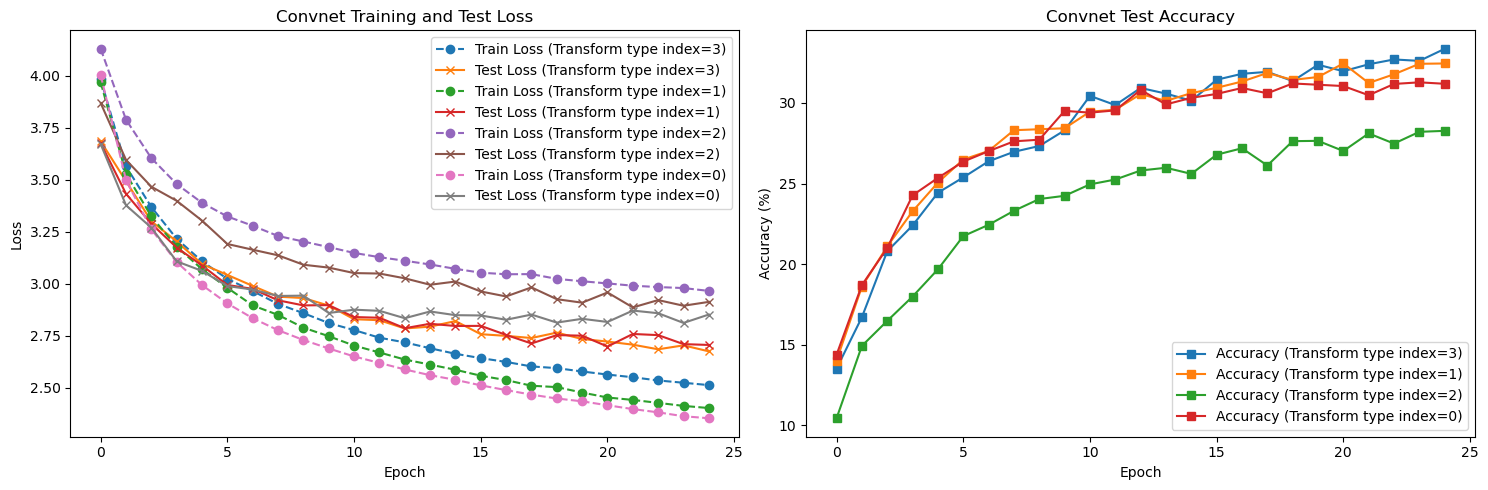

In [37]:
plot_hyperparameter_search_results(transform_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 0}], "Transform type index")
plot_hyperparameter_search_results(transform_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 0}], "Transform type index", "convnet")

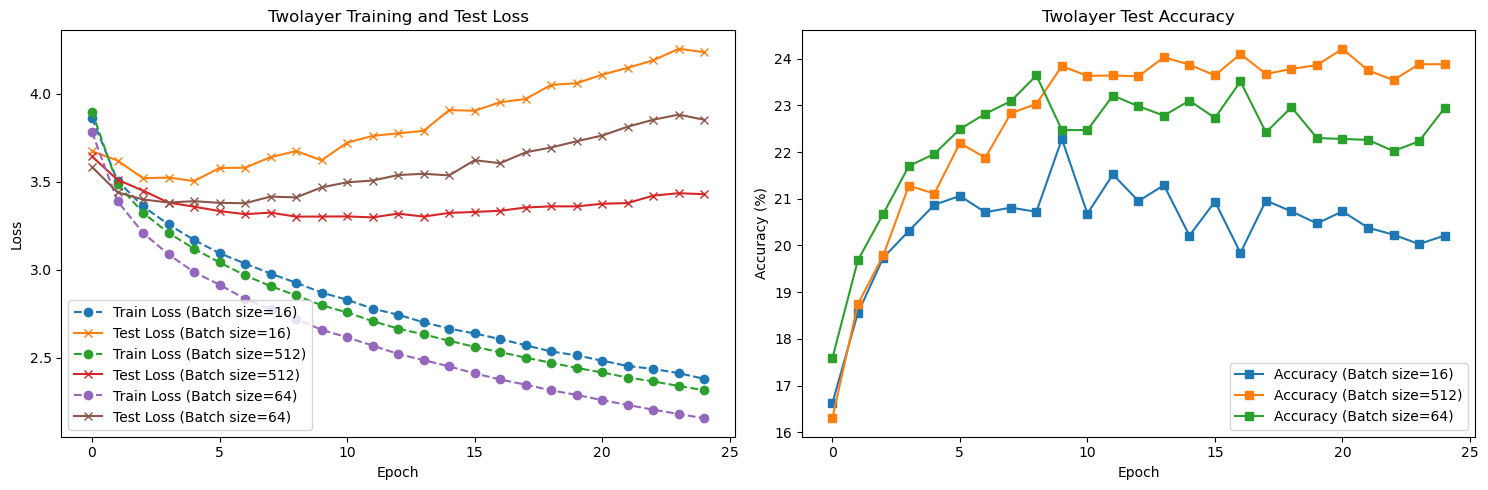

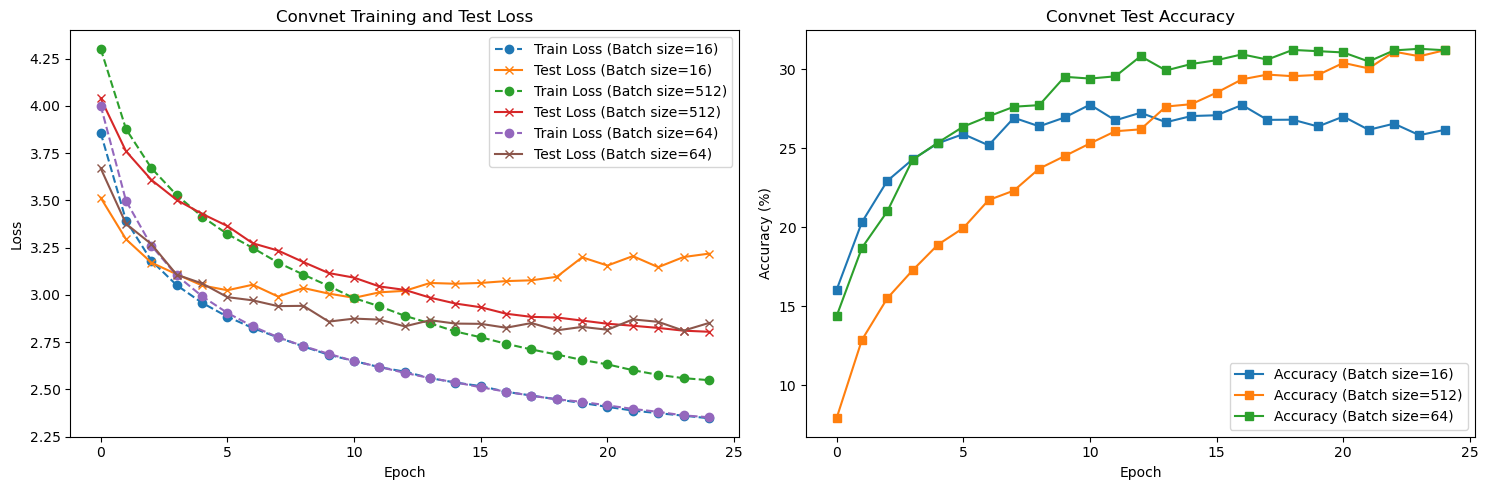

In [38]:
plot_hyperparameter_search_results(batch_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 64}], "Batch size")
plot_hyperparameter_search_results(batch_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 64}], "Batch size", "convnet")

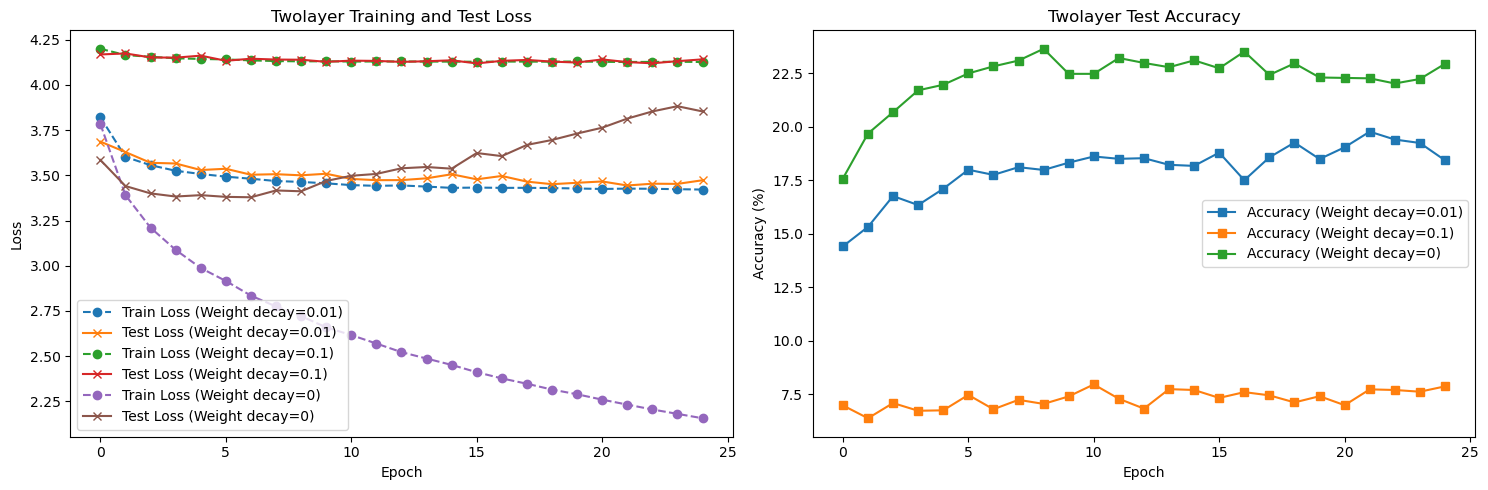

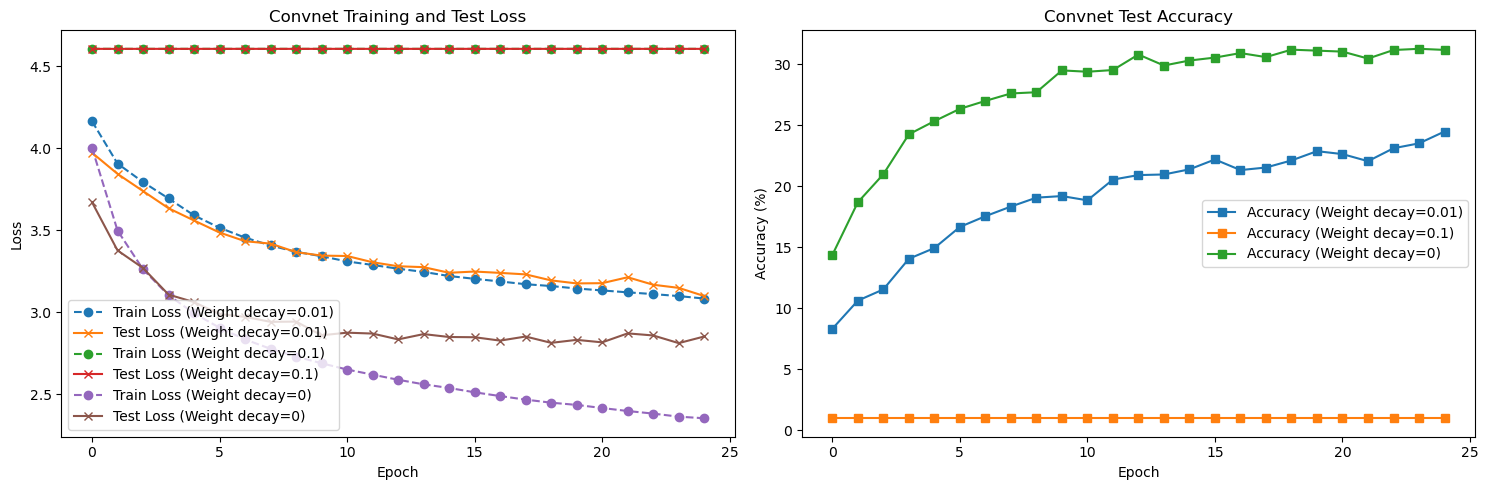

In [39]:
plot_hyperparameter_search_results(decay_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 0}], "Weight decay")
plot_hyperparameter_search_results(decay_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 0}], "Weight decay", "convnet")

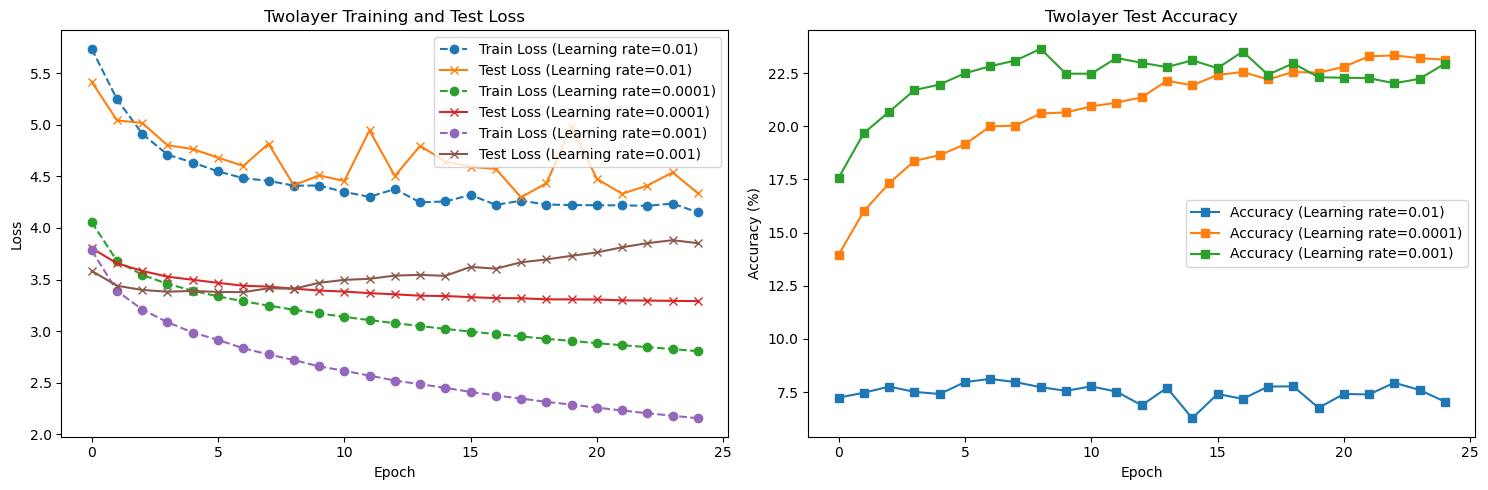

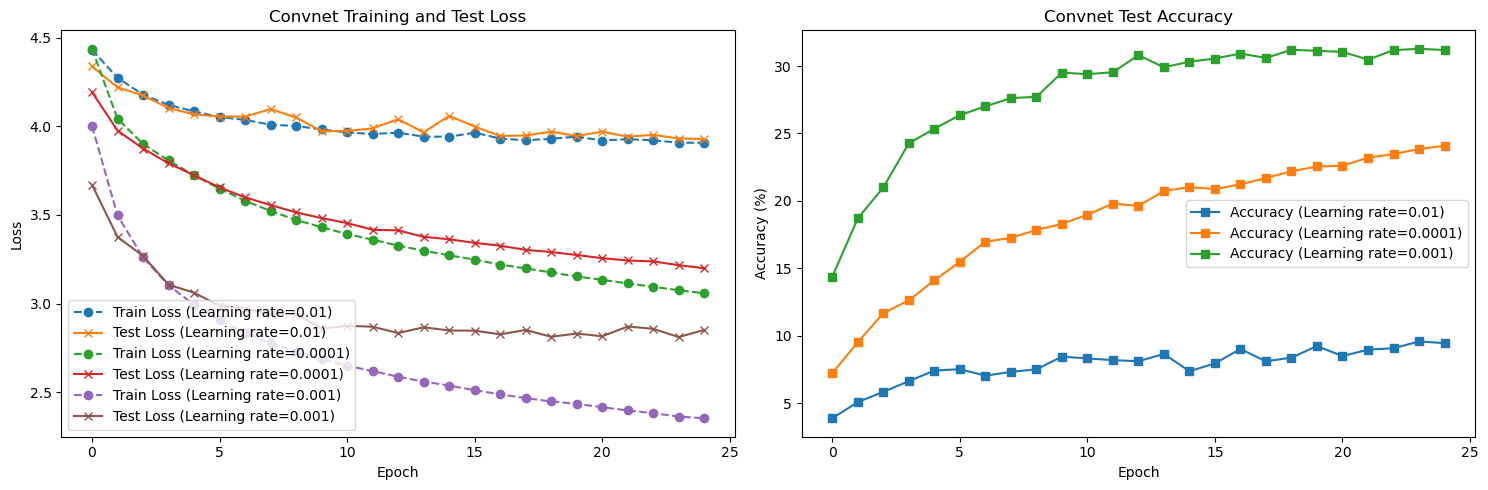

In [40]:
plot_hyperparameter_search_results(lr_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 0.001}], "Learning rate")
plot_hyperparameter_search_results(lr_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": 0.001}], "Learning rate", "convnet")

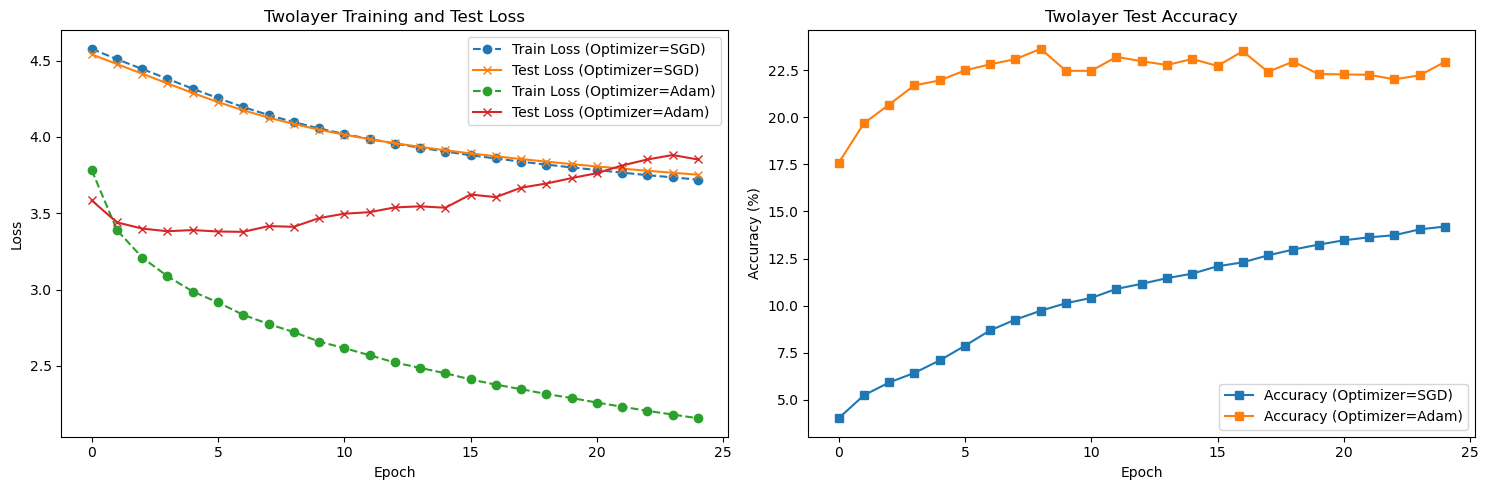

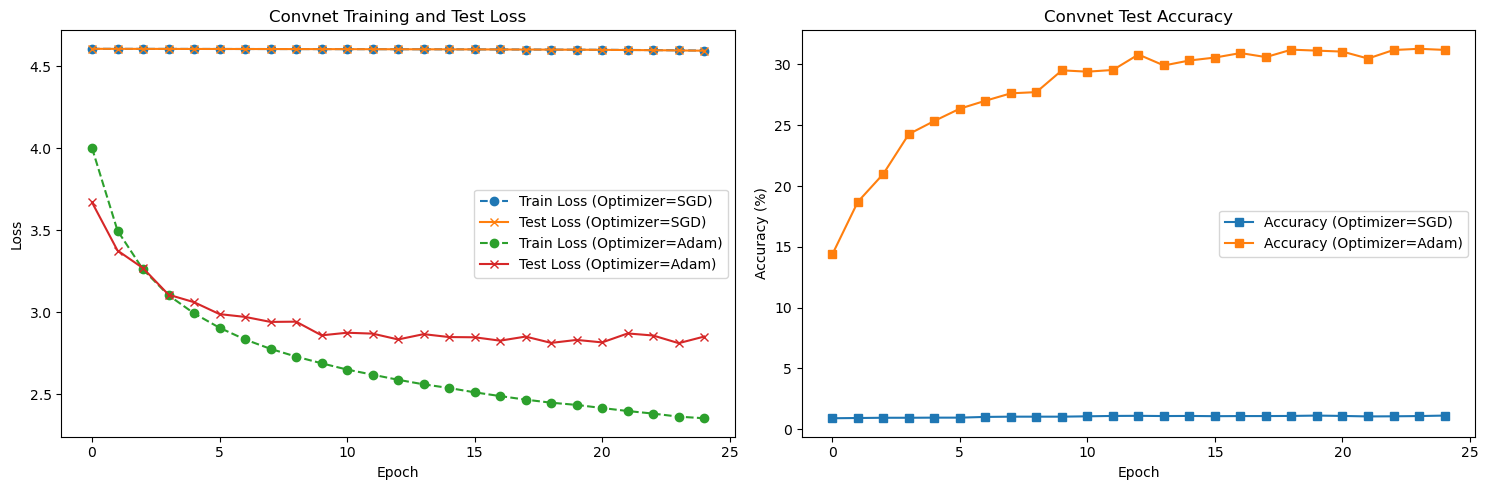

In [41]:
plot_hyperparameter_search_results(optim_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": "Adam"}], "Optimizer")
plot_hyperparameter_search_results(optim_data + [{"twolayer": base_twolayer, "convnet": base_conv, "param": "Adam"}], "Optimizer", "convnet")

Test the performance of ConvNet after hyperparameter tuning and compare it with the TwoLayerNet model. Provide a detailed explanation of the results.

In [42]:
SEED = 42
torch.manual_seed(SEED)  # For PyTorch
np.random.seed(SEED)      # For NumPy

# Set the CUDA seed if you are using a GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

transform = create_transforms(True, 1, 5, True)
test_transforms = create_test_transforms()

train_set = CIFAR100_loader(root='./data', train=True, transform=transform, download=True)
# No random transforms on the test set
test_set = CIFAR100_loader(root='./data', train=False, transform=test_transforms, download=True)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, pin_memory=True)

# Initialize models
two_layer_net = TwoLayerNet(input_size=3*32*32, hidden_size=80, num_classes=100, conv=True, hidden_size2=80, batch_norm=True)
conv_net = ConvNet(conv=True)

criterion = nn.CrossEntropyLoss() # Cross entropy cause classes
optimizer_two_layer = create_optimizer(two_layer_net, learning_rate=0.0005, weight_decay=0.001)
optimizer_conv_net = create_optimizer(conv_net, learning_rate=0.0005, weight_decay=0.001)

Files already downloaded and verified
Files already downloaded and verified


In [43]:
# print("Training TwoLayerNet final...")
# twolayer_final_training_data = train(two_layer_net, train_loader, test_loader, criterion, optimizer_two_layer, epochs=50, save_best="TwoLayerV2.2", existing_accuracy=final_twolayer['accuracy'], existing_train_loss=final_twolayer['train_loss'], existing_test_loss=final_twolayer['test_loss'])

In [44]:
# print("Training Convnet final...")
# convnet_final_training_data = train(conv_net, train_loader, test_loader, criterion, optimizer_conv_net, epochs=50, save_best="ConvNetV2.2", existing_accuracy=final_conv['accuracy'], existing_test_loss=final_conv['test_loss'], existing_train_loss=final_conv['train_loss'])

In [45]:
import json
# with open('resultsTLFinal.json', 'w') as f:
#     json.dump(twolayer_final_training_data, f)
# with open('resultsCNFinal.json', 'w') as f:
#     json.dump(convnet_final_training_data, f)

In [46]:
with open('resultsTLFinal.json', 'r') as f:
    final_twolayer = json.load(f)
with open('resultsCNFinal.json', 'r') as f:
    final_conv = json.load(f)

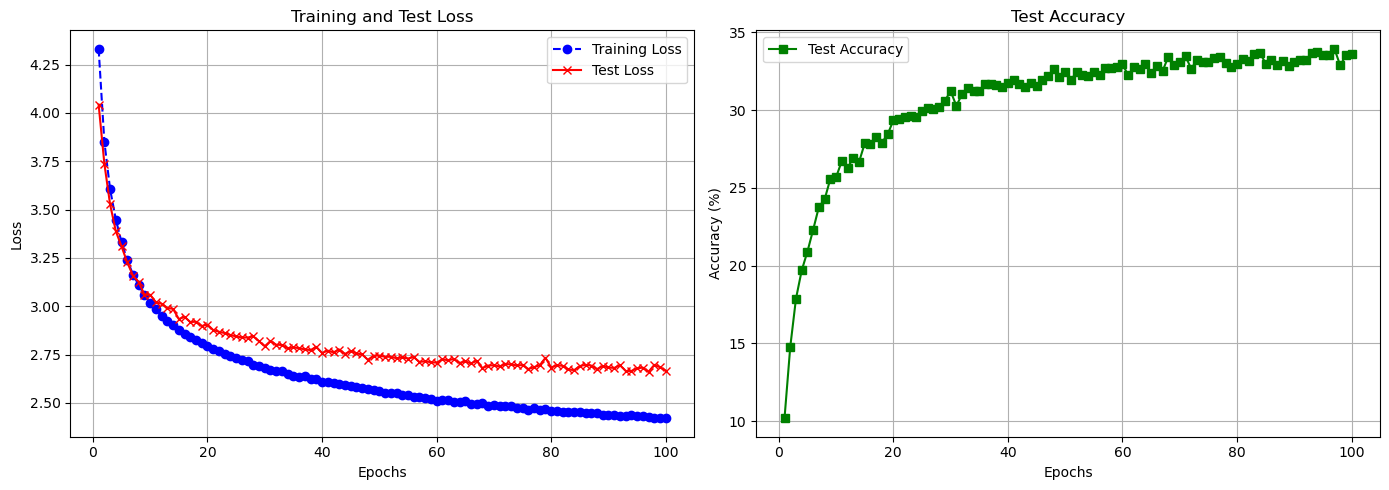

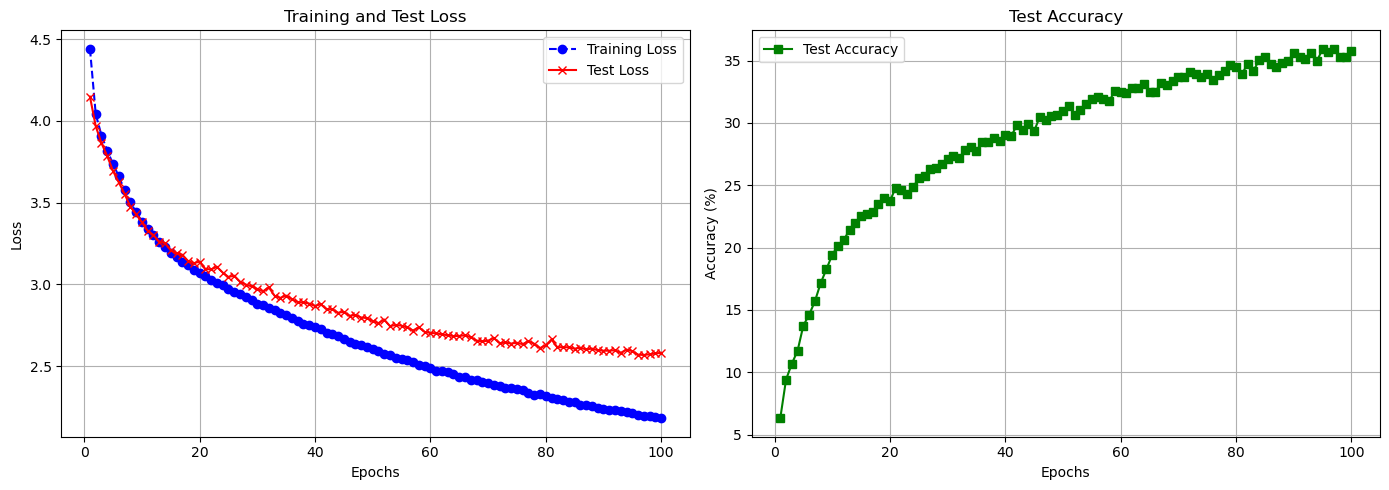

In [47]:
plot_training_results(final_twolayer)
plot_training_results(final_conv)

In [48]:
print(max(final_twolayer['accuracy']))
print(max(final_conv['accuracy']))

33.95
35.95


<a id="section-8"></a>
### **Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)**

In this section, you will work with a subset of the [STL-10](https://cs.stanford.edu/~acoates/stl10/) dataset, containing higher resolution images and different object classes than CIFAR-100. Before fine-tuning your ConvNet on this dataset, first complete the `visualise_stl10` function to display sample images from the following 5 classes:

1. **Bird**
2. **Deer**
3. **Dog**
4. **Horse**
5. **Monkey**

In [49]:
def visualise_stl10(class_mapping : dict):
    '''
    Visualizes 5 images from each specified class in the STL-10 dataset.

    Args:
        class_mapping (dict): A dictionary mapping class indices to class names.
    '''

    dataset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=None)

    images_per_class = {class_name: [] for class_name in class_mapping.values()}

    for img, label in dataset:
        class_name = class_mapping.get(label)
        if class_name and len(images_per_class[class_name]) < 5:
            images_per_class[class_name].append(img)

        # Stop once we have 5 images from each class
        if all(len(images) == 5 for images in images_per_class.values()):
            break

    fig, axes = plt.subplots(len(class_mapping), 5, figsize=(15, 10))

    for i, (class_name, images) in enumerate(images_per_class.items()):
        for j, img in enumerate(images):
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(class_name)

    plt.tight_layout()
    plt.show()

Files already downloaded and verified


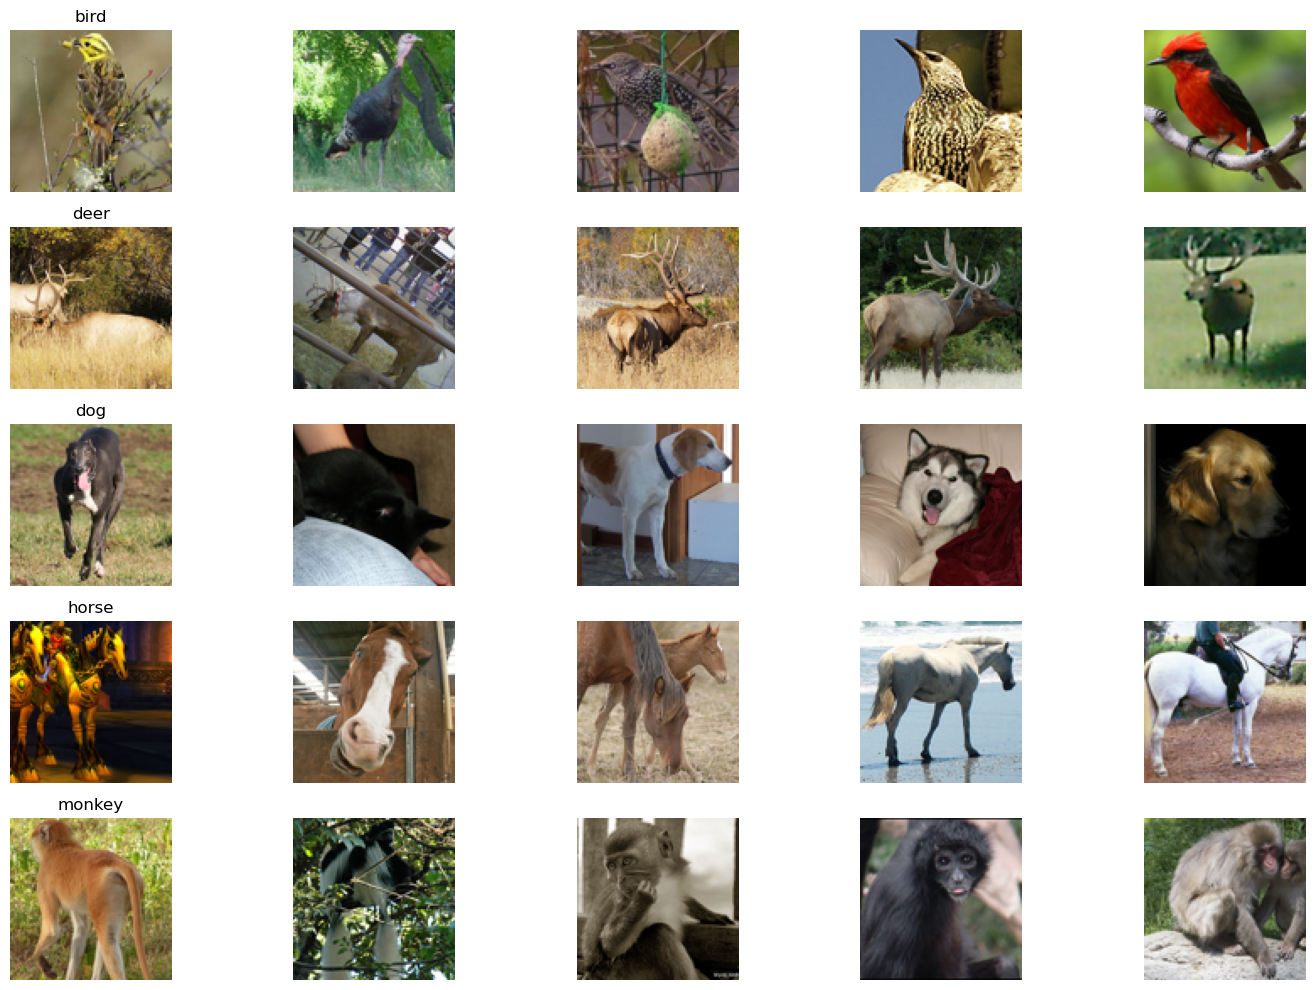

In [50]:
# Define the class mapping for bird, deer, dog, horse, and monkey
class_mapping = {1: 'bird', 4: 'deer', 5: 'dog', 6: 'horse', 7: 'monkey'}

# Visualize STL-10 classes
visualise_stl10(class_mapping)

After visualizing the data, implement the `STL10_loader` class to create a custom data loader that initializes the dataset, extracts the target classes, and applies the necessary image transformations. Once these tasks are completed, you will move on to fine-tuning the ConvNet on this dataset in the next section.

In [51]:
class STL10_loader(Dataset):
    def __init__(self, root, train=True, transform=None, target_classes=None):
        '''
        Initializes the STL10 dataset.

        Args:
            root (str): Root directory of the dataset.
            train (bool): If True, use the training set, otherwise use the test set.
            transform (callable, optional): A function/transform to apply to the images.
            target_classes (list, optional): A list of target classes to extract from the dataset (e.g., bird, deer).
        '''
        self.dataset = torchvision.datasets.STL10(root=root, split='train' if train else 'test', download=True)
        self.transform = transform

        # Filter the dataset to include only the specified target classes
        if target_classes:
            # Create a mapping of names to class indices
            class_idx_mapping = {v: k for k, v in enumerate(self.dataset.classes)}
            # Get the indices of the target classes
            target_indices = [class_idx_mapping[cls] for cls in target_classes]

            # Filter dataset to include only target classes
            self.filtered_data = [(img, label) for img, label in zip(self.dataset.data, self.dataset.labels) if label in target_indices]

            self.label_mapping = {label: i for i, label in enumerate(target_indices)}
        else:
            self.filtered_data = list(zip(self.dataset.data, self.dataset.labels))

    def __len__(self):
        '''
        Returns the number of samples in the dataset.
        '''
        return len(self.filtered_data)

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the transformed image and its target label.
        '''
        img, label = self.filtered_data[idx]

        # Make sure labels are from 0 to 4.
        label = self.label_mapping[label]

        img = Image.fromarray(np.transpose(img, (1, 2, 0)))

        # Apply transformations if provided
        if self.transform:
            img = self.transform(img)

        return img, label

<a id="section-9"></a>
### **Section 9: Fine-tuning ConvNet on STL-10 (14 points)**

In this section, you will load the pre-trained parameters of the ConvNet (trained on CIFAR-100) and modify the output layer to adapt it to the new dataset containing 5 classes. You can either first load the pre-trained parameters and then modify the output layer, or change the output layer before loading the matched pre-trained parameters. Once modified, you will train the model and document the settings of hyperparameters, accuracy, and learning curve. Additionally, visualize both the training loss and accuracy to assess the learning process. To gain a deeper understanding of the feature learning process, consider using techniques like [**t-sne**](https://lvdmaaten.github.io/tsne/) for feature space visualization.

In [52]:
def create_stl10_transforms(flip = True, crop = 4, rot = 0, col = False):
    '''
    Creates the data transformations for the STL-10 dataset.

    Returns:
        torchvision.transforms.Compose: The data transformations for the dataset.
    '''

    transform = transforms.Compose([
        (transforms.RandomHorizontalFlip() if flip else NoneTransform()),
        (transforms.RandomCrop(96, padding=crop) if crop else NoneTransform()), # Alter crop size to match image size.
        (transforms.RandomRotation(rot) if rot else NoneTransform()),
        (transforms.ColorJitter(brightness= 0.01, saturation=0.01, hue=0.01) if col else NoneTransform()),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    return transform

In [53]:
class STL10ConvNet(nn.Module):

    def __init__(self, batch_norm = False):
        '''
        Initializes the convolutional neural network model.

        Args:
            None
        '''
        super(STL10ConvNet, self).__init__()

        if (batch_norm):
            self.batch_norm_1 = nn.BatchNorm2d(6)
            self.batch_norm_2 = nn.BatchNorm2d(16)
        else:
            self.batch_norm_1 = None
            self.batch_norm_2 = None


        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)  # 32x32 -> 28x28 (no padding)

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3)  # 14x14 -> 12x12

        self.conv4 = nn.Conv2d(in_channels=16, out_channels=48, kernel_size=3) # 12x12 -> 10x10

        self.conv3 = nn.Conv2d(in_channels=48, out_channels=240, kernel_size=5)  # 5x5 -> 1x1

        self.fc1 = nn.Linear(240, 84)
        self.fc3 = nn.Linear(84, 84)
        self.fc_new_out = nn.Linear(84, 5)

        self.relu = nn.ReLU()

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''

        # Change image size to allow rest of model to be the same
        x = nn.AdaptiveAvgPool2d((32, 32))(x)

        c1 = self.relu(self.conv1(x))  # Output: (6, 28, 28)
        if self.batch_norm_1:
            c1 = self.batch_norm_1(c1)
        s2 = nn.MaxPool2d(2)(c1)  # Output: (6, 14, 14)

        c3 = self.relu(self.conv2(s2))  
        if self.batch_norm_2:
            c3 = self.batch_norm_2(c3)
        c3 = self.conv4(c3) # Output: (48, 10, 10)

        s4 = nn.MaxPool2d(2)(c3)  # Output: (48, 5, 5)

        c5 = self.relu(self.conv3(s4))  # Output: (240, 1, 1)

        # Flatten the output from (240, 1, 1) to (240)
        c5 = c5.view(-1, 240)

        f6 = self.relu(self.fc1(c5))  # Output: (84)
        f6 = self.relu(self.fc3(f6))  # Output: (84)
        out = self.fc_new_out(f6)  # Output: (5) (class scores)

        return out


In [56]:
base_model = STL10ConvNet(True)
# Trained on GPU, but load in CPU for convenience
base_model.load_state_dict(torch.load('BESTConvNetV2.2.pth', map_location=torch.device('cpu')), strict=False)

transform = create_stl10_transforms(True, 1, 5, True)
transform2 = create_stl10_transforms(True, 4, 15, True)
transform3 = create_stl10_transforms(True, 8, 20, True)
test_transform = create_test_transforms()

target_classes = ['bird', 'deer', 'dog', 'horse', 'monkey']
stl10_train_loader = STL10_loader(root='./data', train=True, transform=transform3, target_classes=target_classes)
stl10_test_loader = STL10_loader(root='./data', train=False, transform=test_transform, target_classes=target_classes)

train_loader = DataLoader(stl10_train_loader, batch_size=512, shuffle=True)
test_loader = DataLoader(stl10_test_loader, batch_size=512, shuffle=False)

criterion = nn.CrossEntropyLoss() # Cross entropy cause classes
optimizer_stl10 = create_optimizer(base_model, learning_rate=0.00025, weight_decay=0.01) # Half learning rate of previous because of the knowledge transfer

Files already downloaded and verified
Files already downloaded and verified


In [57]:
# print("Training for stl10")
# stl10data = train(base_model, train_loader, test_loader, criterion, optimizer_stl10, epochs=50, save_best="stl10wd001t3bnTrue")

In [58]:
import json
# with open('resultsSTL10wd001t3bnTrue.json', 'w') as f:
#     json.dump(stl10data, f)

In [59]:
# The best results: transform2, wd 0.01
with open('resultsSTL10V4.json', 'r') as f:
    stl10data = json.load(f)

In [60]:
print(max(stl10data['accuracy']))

56.65


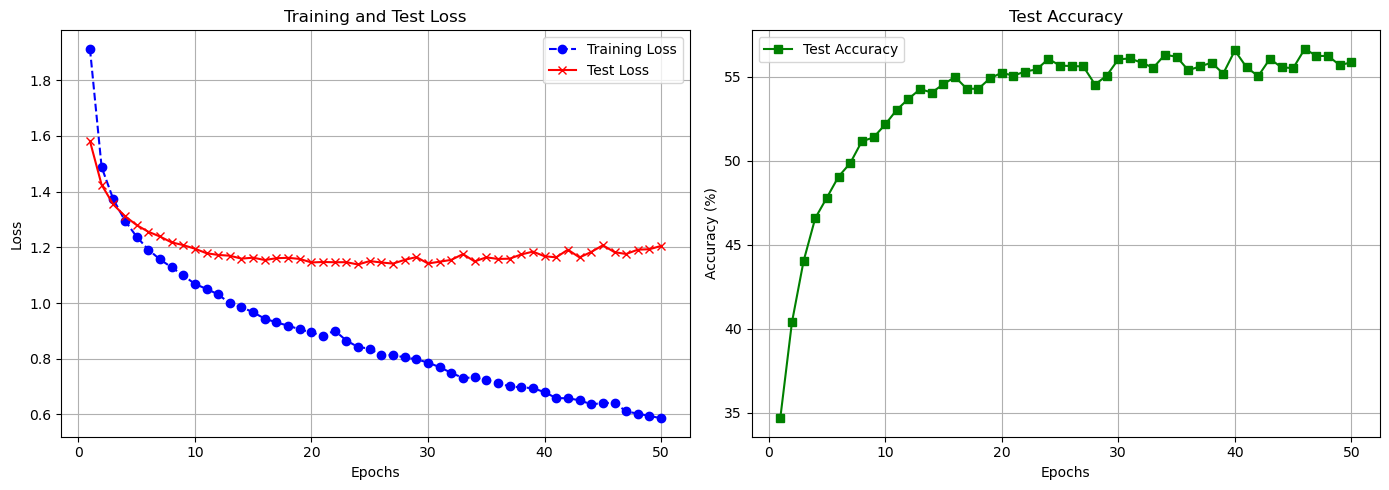

In [61]:
plot_training_results(stl10data)

In [62]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def compute_confusion_matrix(model, test_loader, num_classes, device="cuda"):
    '''
    Computes the confusion matrix for a given model and test data loader.

    Args:
        model (torch.nn.Module): The trained model to evaluate.
        test_loader (torch.utils.data.DataLoader): The test data loader.
        num_classes (int): Number of classes in the classification task.
        device (str): The device to run the model on ('cuda' or 'cpu').

    Returns:
        np.ndarray: Confusion matrix.
    '''
    # Set model to evaluation mode
    model.eval()

    # Initialize variables to track true labels and predictions
    all_preds = []
    all_labels = []

    with torch.no_grad():  # Disable gradient calculations for inference
        for images, labels in test_loader:
            # Move images and labels to the selected device
            images, labels = images.to(device), labels.to(device)

            # Forward pass to get model predictions
            outputs = model(images)
            _, preds = torch.max(outputs, 1)  # Get the class with highest probability

            # Append predictions and true labels to lists
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Flatten the lists into 1D arrays
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    return conf_matrix

def plot_confusion_matrix(conf_matrix, class_names):
    '''
    Plots the confusion matrix using seaborn heatmap.

    Args:
        conf_matrix (np.ndarray): The confusion matrix to plot.
        class_names (list): List of class names corresponding to each label index.
    '''
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

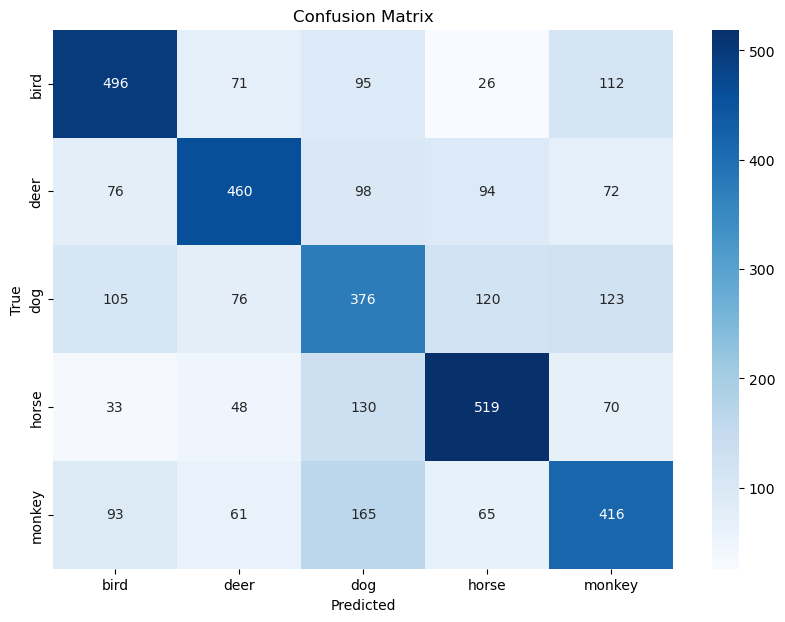

In [64]:
testing_model = STL10ConvNet(False)
testing_model.load_state_dict(torch.load("BESTstl10V3.pth", map_location=torch.device('cpu')))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
testing_model.to(device)

num_classes = 5
conf_matrix = compute_confusion_matrix(testing_model, test_loader, num_classes, device="cpu")

plot_confusion_matrix(conf_matrix, target_classes)

In [66]:
# This model is for extracting the final feature layer.
class TSNESTL10ConvNet(nn.Module):

    def __init__(self, batch_norm = False):
        '''
        Initializes the convolutional neural network model.

        Args:
            None
        '''
        super(TSNESTL10ConvNet, self).__init__()

        if (batch_norm):
            self.batch_norm_1 = nn.BatchNorm2d(6)
            self.batch_norm_2 = nn.BatchNorm2d(16)
        else:
            self.batch_norm_1 = None
            self.batch_norm_2 = None


        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)  # 32x32 -> 28x28 (no padding)

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3)  # 14x14 -> 12x12

        self.conv4 = nn.Conv2d(in_channels=16, out_channels=48, kernel_size=3) # 12x12 -> 10x10

        self.conv3 = nn.Conv2d(in_channels=48, out_channels=240, kernel_size=5)  # 5x5 -> 1x1

        self.fc1 = nn.Linear(240, 84)
        self.fc3 = nn.Linear(84, 84)
        self.fc_new_out = nn.Linear(84, 5)

        self.relu = nn.ReLU()

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''

        # Change image size to allow rest of model to be the same
        x = nn.AdaptiveAvgPool2d((32, 32))(x)

        c1 = self.relu(self.conv1(x))  # Output: (6, 28, 28)
        if self.batch_norm_1:
            c1 = self.batch_norm_1(c1)
        s2 = nn.MaxPool2d(2)(c1)  # Output: (6, 14, 14)

        c3 = self.relu(self.conv2(s2))  
        if self.batch_norm_2:
            c3 = self.batch_norm_2(c3)
        c3 = self.conv4(c3) # Output: (48, 10, 10)

        s4 = nn.MaxPool2d(2)(c3)  # Output: (48, 5, 5)

        c5 = self.relu(self.conv3(s4))  # Output: (240, 1, 1)

        # Flatten the output from (240, 1, 1) to (240)
        c5 = c5.view(-1, 240)

        f6 = self.relu(self.fc1(c5))  # Output: (84)
        out = self.relu(self.fc3(f6))  # Output: (84)

        return out


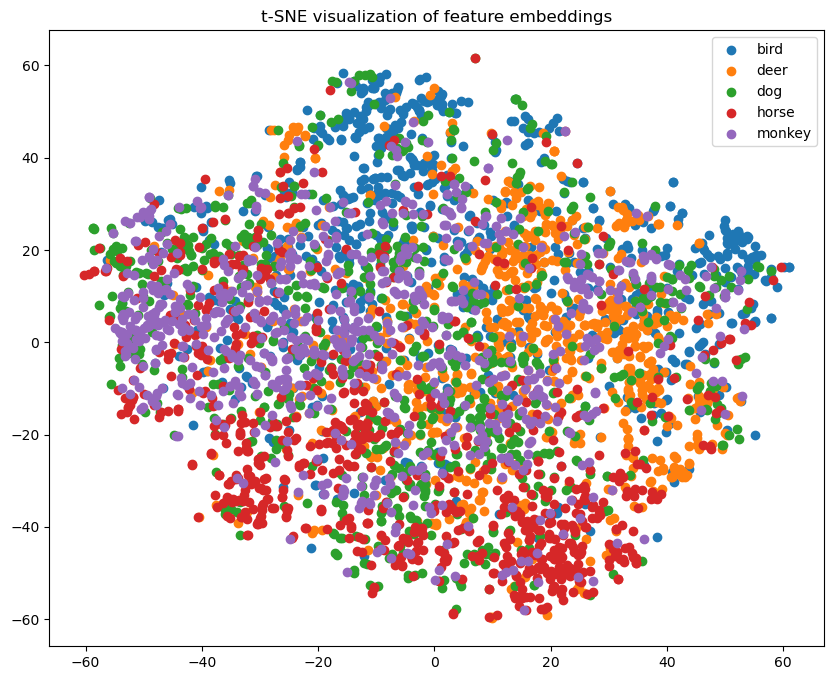

In [68]:
from sklearn.manifold import TSNE

def extract_features(model, data_loader, device="cuda"):
    '''
    Extracts feature embeddings from a model given a data loader.

    Args:
        model (torch.nn.Module): The trained model used to extract features.
        data_loader (torch.utils.data.DataLoader): DataLoader for the dataset.
        device (str): The device on which to perform computations.

    Returns:
        tuple: (feature embeddings, corresponding labels)
    '''
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for images, lbls in data_loader:
            images = images.to(device)

            # Get the model's embeddings (e.g., before the final layer)
            outputs = model(images)

            # Assuming that `outputs` contains the feature representations
            features.append(outputs.cpu().numpy())
            labels.append(lbls.cpu().numpy())

    features = np.concatenate(features, axis=0)  # Shape: (num_samples, num_features)
    labels = np.concatenate(labels, axis=0)  # Shape: (num_samples,)

    return features, labels

def tsne_visualization(features, labels, class_names):
    '''
    Applies t-SNE on the feature embeddings and visualizes the results.

    Args:
        features (numpy.ndarray): The feature embeddings.
        labels (numpy.ndarray): The ground truth labels corresponding to the features.
        class_names (list): List of class names for the labels.
    '''
    # Apply t-SNE to reduce the feature dimensions to 2D
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(features)

    # Create a scatter plot of the t-SNE results
    plt.figure(figsize=(10, 8))
    for class_idx, class_name in enumerate(class_names):
        idxs = labels == class_idx
        plt.scatter(tsne_results[idxs, 0], tsne_results[idxs, 1], label=class_name)

    plt.title('t-SNE visualization of feature embeddings')
    plt.legend()
    plt.show()

testing_model = TSNESTL10ConvNet(False)
testing_model.load_state_dict(torch.load('BESTstl10V3.pth', map_location=torch.device('cpu')), strict=False)
testing_model.to(device)

# Extract features using the model
features, labels = extract_features(testing_model, test_loader, device="cpu")

# Visualize using t-SNE
tsne_visualization(features, labels, target_classes)

We're getting a different TSNE image than in the report now, but you can still see clear bird, horse and deer clusters, while dog and monkey are more spread out.

<a id="section-10"></a>
### **Section 10: Bonus Challenge (optional)**

Try to achieve the highest possible accuracy on the test dataset (5 classes from STL-10) by adjusting hyperparameters, modifying architectures, or applying techniques like data augmentation. The top-performing teams will earn bonus points that can significantly boost their final lab grade, even allowing it to exceed 10 (up to 11):

- **1st place:** +1.0 to the final grade of the final lab
- **2nd place:** +0.8 to the final grade of the final lab
- **3rd place:** +0.6 to the final grade of the final lab
- **4th place:** +0.4 to the final grade of the final lab
- **5th place:** +0.2 to the final grade of the final lab

**Hint:** You may use techniques like data augmentation, freezing early layers, modifying architecture, or optimizing hyperparameters. Only data from CIFAR-100 and STL-10 can be used, and you cannot add more than 3 additional convolutional layers.

In [64]:
# We got 56.95, but no way that's enough for a bonus, and not enough time or willpower to try for more!

<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
| Alisia Baielli | 33 % | 34 % | 33 % |
| Sander Hoffman | 33 % | 33 % | 34 % |
| Maxim Voronin | 34 % | 33 % | 33 % |
|  | - % | - % | - % |

### - End of Notebook -